# DL079 对称性几何与等变网络

对应S2。按顺序执行；先预测结果再看输出。数据和研究范围见lecture.md。本Notebook实际复跑全部实验，写入notebook_outputs，不覆盖课程参考输出。

In [1]:
from pathlib import Path
import json, sys
# Notebook应在本单元目录启动。
print("Python",sys.version.split()[0])
print("目录",Path.cwd())
if not Path("experiment.py").exists():
    raise RuntimeError("请在当前单元目录运行")

Python 3.12.14
目录 /workspace/scratch/1577d0a62398/course-batch-078-082/dl/units/079


## 先运行数值与边界测试
测试通过不等于科学假设成立，但失败时不要跳过。

In [2]:
import unittest
import test_experiment
# 使用显式unittest检查，不依赖可被-O移除的assert。
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result=unittest.TextTestRunner(verbosity=2).run(suite)
if not result.wasSuccessful():
    raise RuntimeError("测试失败，停止实验")

test_gradient (test_experiment.Tests.test_gradient) ... 

ok


test_group_composition (test_experiment.Tests.test_group_composition) ... 

ok


test_invalid (test_experiment.Tests.test_invalid) ... 

...

test_training (test_experiment.Tests.test_training) ... 

ok


test_translation_relative (test_experiment.Tests.test_translation_relative) ... 

ok


----------------------------------------------------------------------
Ran 11 tests in 0.086s

OK


## 完整复跑
参数、预测和数据都由本次运行重新生成；运行时长取决于机器。

In [3]:
from experiment import run
results=run("notebook_outputs")
print(json.dumps(results,ensure_ascii=False,indent=2))

{
  "equivariant_val_mse": 3.399339370267869e-06,
  "equivariant_max_equivariance_error": 1.3322676295501878e-15,
  "equivariant_test_mse_seeds": [
    2.634178757785518e-06,
    3.420826887946441e-05,
    6.826507245845394e-07
  ],
  "equivariant_test_mse_mean": 1.250836612061149e-05,
  "ordinary_val_mse": 0.20875636140933387,
  "ordinary_max_equivariance_error": 1.6682717206257196,
  "ordinary_test_mse_seeds": [
    0.1371249444835806,
    0.19434296878223156,
    0.23302922342072963
  ],
  "ordinary_test_mse_mean": 0.18816571222884726,
  "augmented_val_mse": 0.040432877804980706,
  "augmented_max_equivariance_error": 0.22522115283911437,
  "augmented_test_mse_seeds": [
    0.03293482465867291,
    0.03029388183120061,
    0.020688160341299833
  ],
  "augmented_test_mse_mean": 0.027972288943724454,
  "translated_relative_error": 8.881784197001252e-16,
  "anisotropic_symmetry_violation": 1.7819880975412916,
  "seconds": 1.1620793350011809,
  "steps": 1600,
  "train_positions": 192,
  

## 先检查一个旋转

In [4]:
import numpy as np
from experiment import rotation, truth
# 样本按行排列，因此右乘R的转置。
r = rotation(np.pi/2)
x = np.array([[1.,0.]])
print("新位置", x @ r.T)
print("新力", truth(x) @ r.T)

新位置 [[6.123234e-17 1.000000e+00]]
新力 [[-5.8170723e-17 -9.5000000e-01]]


## 未训练也应等变

In [5]:
from experiment import data, init, predict
x,_ = data(sector=False)
p = init("equivariant",seed=12)
r = rotation(.731)
# 预测准确性未知，但结构交换关系仍必须成立。
err = predict(x@r.T,p,"equivariant") - predict(x,p,"equivariant")@r.T
print("未训练网络等变误差", np.max(np.abs(err)))

未训练网络等变误差 1.3877787807814457e-16


## 错误对称性反例

In [6]:
x = np.array([[1.,0.]])
r = rotation(np.pi/2)
anisotropic = lambda z: -z*np.array([1.,2.])
# 固定实验室刚度，不随坐标一起旋转，交换关系被破坏。
print("先旋转输入", anisotropic(x@r.T))
print("先旋转输出", anisotropic(x)@r.T)

先旋转输入 [[-6.123234e-17 -2.000000e+00]]
先旋转输出 [[-6.123234e-17 -1.000000e+00]]


## 阅读输出与研究边界
下面显示课程参考图；数值来自本次复跑results，两者的来源请分清。最后用自己的话回答实验册的限制问题。

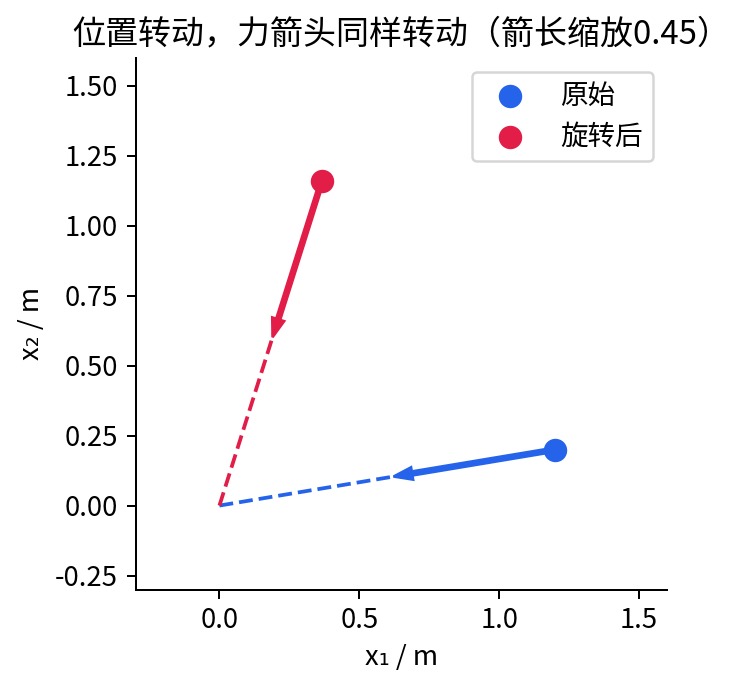

In [7]:
from IPython.display import display, Image
# 图由课程参考outputs重建，这里核验Notebook图像显示。
figure=sorted(Path("figures").glob("*.png"))[0]
display(Image(filename=str(figure),width=640))